# More Gibbs Sampler Examples

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

## Probit Regression

Consider the frogs dataset that we previously used to illustrate Logistic Regression. Here we apply fit the probit regression model to this data. 

In [93]:
frogs = pd.read_csv("frogs.csv")

# Design matrix
X = frogs[['altitude','distance','NoOfPools','NoOfSites','avrain','meanmin','meanmax']].copy()
X['distance'] = np.log(X['distance'])
X['NoOfPools'] = np.log(X['NoOfPools'])
X = sm.add_constant(X)
y = frogs['pres.abs'].values

The GLM function in statsmodels can be used to fit the probit model. 

In [94]:
# GLM (probit + logit)
print(sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.Probit())).fit().summary())
print(sm.GLM(y, X, family=sm.families.Binomial()).fit().summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  212
Model:                            GLM   Df Residuals:                      204
Model Family:                Binomial   Df Model:                            7
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -99.536
Date:                Mon, 06 Apr 2026   Deviance:                       199.07
Time:                        18:01:24   Pearson chi2:                     229.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3173
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.9617     73.193      0.560      0.5

Below is the code for the Gibbs sampler. We are using augmentation and sampling from the joint posterior of $w, \beta$ given the data. Here $w_i 
\overset{\text{i.i.d}}{\sim} N(x_i^T \beta, 1)$ and $y_i = I\{w_i > 0\}$. The conditional distribution of $\beta$ given $w$ and the data is
\begin{align*}
   \beta \mid w, \text{data} \sim N((X^T X)^{-1} X^T w, (X^T X)^{-1}). 
\end{align*}
The conditional distribution of $w$ given $\beta$ and the data is: 
\begin{align*}
   w_i \overset{\text{independent}}{\sim} N(x_i^T \beta, 1) \text{ truncated to } I\{w_i > 0\} = y_i. 
\end{align*}
In other words, if $y_i = 1$, then $w_i$ is distributed as $N(x_i^T \beta, 1)$ conditioned to be positive. And if $y_i = 0$, then $w_i$ is distributed as $N(x_i^T \beta, 1)$ conditioned to be negative. Simulating from the truncated normal distribution can be done as described in https://en.wikipedia.org/wiki/Truncated_normal_distribution#Generating_values_from_the_truncated_normal_distribution.  

In [95]:
from scipy.stats import norm

In [96]:
Xm = X.values
linmod_cov = np.linalg.inv(Xm.T @ Xm)
n, p = Xm.shape
XtX_inv = linmod_cov
Xt = Xm.T
A = XtX_inv @ Xt   # (X^T X)^{-1} X^T

beta_init = A @ y
w_init = Xm @ beta_init
state = np.concatenate([beta_init, w_init])

nit = 100000
path = np.zeros((nit, p+n))
path[0] = state

for t in range(1, nit):
    if np.random.rand() < 0.5:
        #this part updates beta and leaves w fixed
        w = state[p:]
        beta = A @ w  
        path[t,:p] = np.random.multivariate_normal(beta, XtX_inv)
        path[t,p:] = w
    else:
        #this part updates w and leaves beta fixed
        beta = state[:p]
        path[t,:p] = beta

        mu = Xm @ beta   # vectorized
        u = np.random.rand(n)

        mask1 = (y == 1)
        mask0 = ~mask1

        path[t,p:][mask1] = mu[mask1] + norm.ppf(
            u[mask1] + (1-u[mask1])*norm.cdf(-mu[mask1])
        )
        path[t,p:][mask0] = mu[mask0] + norm.ppf(
            u[mask0]*norm.cdf(-mu[mask0])
        )

    state = path[t]
    if t % 2000 == 0: print(t)

2000
4000
6000
8000
10000
12000
14000
16000
18000
20000
22000
24000
26000
28000
30000
32000
34000
36000
38000
40000
42000
44000
46000
48000
50000
52000
54000
56000
58000
60000
62000
64000
66000
68000
70000
72000
74000
76000
78000
80000
82000
84000
86000
88000
90000
92000
94000
96000
98000


Below we compute the posterior means and standard deviations. 

In [97]:
# Posterior summaries
pth = pd.DataFrame(path[:, :p], columns=[f'b{i}' for i in range(p)])
bayes = pd.DataFrame({
    'est': pth.mean(),
    'std.err': pth.std()
})

print(bayes)

          est    std.err
b0  37.712413  73.834205
b1  -0.007667   0.021202
b2  -0.433096   0.143792
b3   0.351701   0.122949
b4   0.002300   0.062390
b5  -0.011269   0.035240
b6   3.142313   0.877072
b7  -2.375448   2.727773


Below we compare the posterior means and standard deviations, with the frequentist estimates and standard errors. Remember that the frequentist estimates and standard errors coincide with the Bayesian solution corresponding to the Laplace posterior normal approximation. 

In [99]:
# GLM (probit)
glm_res = sm.GLM(
    y, Xm,
    family=sm.families.Binomial(link=sm.families.links.Probit())
).fit()

# Combine results
comp = pd.DataFrame({
    'Bayes_est': bayes['est'].values,
    'GLM_est': glm_res.params,
    'Bayes_se': bayes['std.err'].values,
    'GLM_se': glm_res.bse
}, index=[f'b{i}' for i in range(len(glm_res.params))])

print(comp)

    Bayes_est    GLM_est   Bayes_se     GLM_se
b0  37.712413  40.961673  73.834205  73.192736
b1  -0.007667  -0.009011   0.021202   0.021139
b2  -0.433096  -0.417042   0.143792   0.144002
b3   0.351701   0.339612   0.122949   0.121531
b4   0.002300   0.004392   0.062390   0.062026
b5  -0.011269  -0.010206   0.035240   0.034128
b6   3.142313   2.965350   0.877072   0.862714
b7  -2.375448  -2.436715   2.727773   2.700422


It is clear that the Gibbs sampler gives very similar results to those obtained by the Laplace posterior normal approximation. 

## Simulation Setting

The following simulation setting uses a very small sample size $n = 15$. Here there will be more discrepancy between the Gibbs sampler and the Laplace posterior normal approximation. 

In [100]:
n = 15
beta_0 = -4.0
beta_1 = 0.8

# for reproducibility
np.random.seed(42)

# generate x
x = np.random.normal(loc=5, scale=0.75, size=n)

# compute probit probabilities
probs = norm.cdf(beta_0 + beta_1 * x)

# generate y
y = np.random.binomial(1, probs, size=n)

print("x =", x)
print("p =", probs)
print("y =", y)

x = [5.37253561 4.89630177 5.4857664  6.14227239 4.82438497 4.82439728
 6.18440961 5.57557605 4.64789421 5.40692003 4.65243673 4.65070268
 5.1814717  3.56503982 3.70631163]
p = [0.61715929 0.46694224 0.65121882 0.81959373 0.44413563 0.44413952
 0.82831502 0.67740726 0.38909267 0.62761229 0.39048675 0.38995441
 0.55771458 0.12549086 0.15034597]
y = [1 0 1 1 0 1 1 1 0 1 0 0 1 1 1]


Below we compute the Laplace posterior normal approximation (i.e., the frequentist estimates and standard errors). 

In [102]:
# design matrix with intercept
X = sm.add_constant(x)

# fit probit regression
model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(link=sm.families.links.Probit())
)

result = model.fit()

print(result.summary())
print("\nEstimated coefficients:")
print("beta_0_hat =", result.params[0])
print("beta_1_hat =", result.params[1])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   15
Model:                            GLM   Df Residuals:                       13
Model Family:                Binomial   Df Model:                            1
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8.9535
Date:                Mon, 06 Apr 2026   Deviance:                       17.907
Time:                        18:05:03   Pearson chi2:                     14.1
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07617
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2020      2.453     -0.898      0.3

Next we implement the Gibbs sampler. 

In [105]:
n, p = X.shape
linmod_cov = np.linalg.inv(X.T @ X)
print(linmod_cov)


[[ 3.28868367 -0.64340466]
 [-0.64340466  0.12848149]]


In [109]:
Xm = X
XtX_inv = linmod_cov
Xt = Xm.T
A = XtX_inv @ Xt   # (X^T X)^{-1} X^T

beta_init = A @ y
w_init = Xm @ beta_init
state = np.concatenate([beta_init, w_init])

nit = 500000
path = np.zeros((nit, p+n))
path[0] = state

for t in range(1, nit):
    if np.random.rand() < 0.5:
        w = state[p:]
        beta = A @ w  
        path[t,:p] = np.random.multivariate_normal(beta, XtX_inv)
        path[t,p:] = w
    else:
        beta = state[:p]
        path[t,:p] = beta

        mu = Xm @ beta   # vectorized
        u = np.random.rand(n)

        mask1 = (y == 1)
        mask0 = ~mask1

        path[t,p:][mask1] = mu[mask1] + norm.ppf(
            u[mask1] + (1-u[mask1])*norm.cdf(-mu[mask1])
        )
        path[t,p:][mask0] = mu[mask0] + norm.ppf(
            u[mask0]*norm.cdf(-mu[mask0])
        )

    state = path[t]
    if t % 2000 == 0: print(t)

2000
4000
6000
8000
10000
12000
14000
16000
18000
20000
22000
24000
26000
28000
30000
32000
34000
36000
38000
40000
42000
44000
46000
48000
50000
52000
54000
56000
58000
60000
62000
64000
66000
68000
70000
72000
74000
76000
78000
80000
82000
84000
86000
88000
90000
92000
94000
96000
98000
100000
102000
104000
106000
108000
110000
112000
114000
116000
118000
120000
122000
124000
126000
128000
130000
132000
134000
136000
138000
140000
142000
144000
146000
148000
150000
152000
154000
156000
158000
160000
162000
164000
166000
168000
170000
172000
174000
176000
178000
180000
182000
184000
186000
188000
190000
192000
194000
196000
198000
200000
202000
204000
206000
208000
210000
212000
214000
216000
218000
220000
222000
224000
226000
228000
230000
232000
234000
236000
238000
240000
242000
244000
246000
248000
250000
252000
254000
256000
258000
260000
262000
264000
266000
268000
270000
272000
274000
276000
278000
280000
282000
284000
286000
288000
290000
292000
294000
296000
298000
300000
302

Below are the posterior means and standard errors (after removing a burnin). 

In [110]:
# Posterior summaries with burn-in
burnin = 5000

pth = pd.DataFrame(path[burnin:, :p], columns=[f'b{i}' for i in range(p)])
bayes = pd.DataFrame({
    'est': pth.mean(),
    'std.err': pth.std()
})

print(bayes)

         est   std.err
b0 -2.376342  2.525091
b1  0.580037  0.516160


Below we print the posteior means and standard errors side by side with the frequentist estimates and standard errors. 

In [112]:
# GLM (probit)
glm_res = sm.GLM(
    y, Xm,
    family=sm.families.Binomial(link=sm.families.links.Probit())
).fit()

# Combine results
comp = pd.DataFrame({
    'Bayes_est': bayes['est'].values,
    'GLM_est': glm_res.params,
    'Bayes_se': bayes['std.err'].values,
    'GLM_se': glm_res.bse
}, index=[f'b{i}' for i in range(len(glm_res.params))])

print(comp)

    Bayes_est   GLM_est  Bayes_se    GLM_se
b0  -2.376342 -2.201963  2.525091  2.453266
b1   0.580037  0.535108  0.516160  0.492885


Which of these two outputs better approximates the true posterior? This question is harder to answer in general but since this is a scenario with only two parameters, we can attempt to compute the actual posterior using a dense grid-based numerical approximation. We do this below. 


Grid posterior summaries:
Posterior mean beta_0 = -2.371029301192905
Posterior sd   beta_0 = 2.5215968840131513
Posterior mean beta_1 = 0.5788161540054721
Posterior sd   beta_1 = 0.5159341483896762


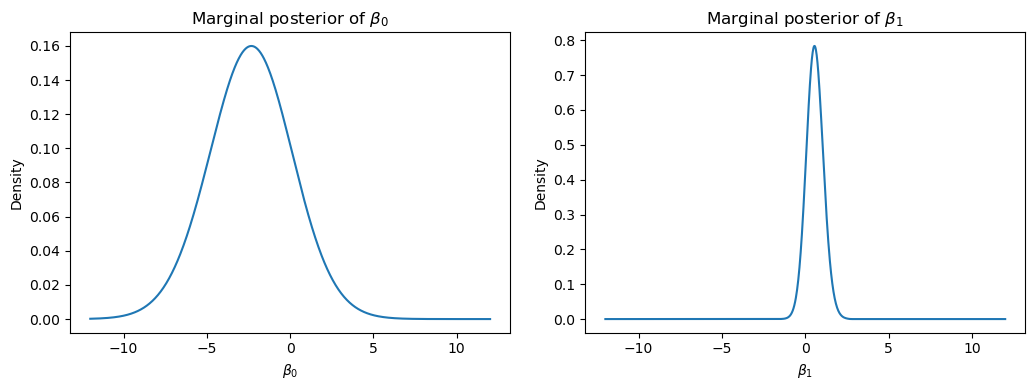

In [117]:
from scipy.special import logsumexp
# -----------------------------
# Grid posterior computation
# -----------------------------

# center grid around MLE
b0_hat, b1_hat = result.params
se0, se1 = result.bse

# choose a grid range (we are placing the grid around a large range)
b0_grid = np.linspace(-12.0, 12.0, 1000)
b1_grid = np.linspace(-12.0, 12.0, 1000)

B0, B1 = np.meshgrid(b0_grid, b1_grid, indexing="xy")

log_post = np.zeros_like(B0)

# compute log-likelihood on the grid
for i in range(len(b1_grid)):
    for j in range(len(b0_grid)):
        beta = np.array([B0[i, j], B1[i, j]])
        eta = X @ beta
        p = norm.cdf(eta)

        # avoid log(0)
        p = np.clip(p, 1e-14, 1 - 1e-14)

        loglik = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        log_post[i, j] = loglik   # flat prior => log posterior = log likelihood + constant

# normalize numerically
log_post_norm = log_post - logsumexp(log_post)
post = np.exp(log_post_norm)

# account for grid cell area so posterior integrates to about 1
db0 = b0_grid[1] - b0_grid[0]
db1 = b1_grid[1] - b1_grid[0]
post = post / (post.sum() * db0 * db1)

# -----------------------------
# Posterior summaries from grid
# -----------------------------
# marginals
post_b0 = post.sum(axis=0) * db1
post_b1 = post.sum(axis=1) * db0

# posterior means
mean_b0 = np.sum(b0_grid * post_b0) * db0
mean_b1 = np.sum(b1_grid * post_b1) * db1

# posterior variances
var_b0 = np.sum((b0_grid - mean_b0)**2 * post_b0) * db0
var_b1 = np.sum((b1_grid - mean_b1)**2 * post_b1) * db1

print("\nGrid posterior summaries:")
print("Posterior mean beta_0 =", mean_b0)
print("Posterior sd   beta_0 =", np.sqrt(var_b0))
print("Posterior mean beta_1 =", mean_b1)
print("Posterior sd   beta_1 =", np.sqrt(var_b1))

# -----------------------------
# Plots
# -----------------------------
plt.figure(figsize=(15, 4))

# marginal for beta_0
plt.subplot(1, 3, 2)
plt.plot(b0_grid, post_b0)
plt.xlabel(r'$\beta_0$')
plt.ylabel("Density")
plt.title(r"Marginal posterior of $\beta_0$")

# marginal for beta_1
plt.subplot(1, 3, 3)
plt.plot(b1_grid, post_b1)
plt.xlabel(r'$\beta_1$')
plt.ylabel("Density")
plt.title(r"Marginal posterior of $\beta_1$")

plt.tight_layout()
plt.show()

Below we plot all the estimates (and standard errors) side-by-side for comparison. 

In [119]:
comp = pd.DataFrame({
    'Bayes_est': bayes['est'].values[:2],
    'GLM_est': glm_res.params[:2],
    'Grid_est': [mean_b0, mean_b1],
    'Bayes_se': bayes['std.err'].values[:2],
    'GLM_se': glm_res.bse[:2],
    'Grid_se': [np.sqrt(var_b0), np.sqrt(var_b1)]
}, index=['b0', 'b1'])

print(comp)

    Bayes_est   GLM_est  Grid_est  Bayes_se    GLM_se   Grid_se
b0  -2.376342 -2.201963 -2.371029  2.525091  2.453266  2.521597
b1   0.580037  0.535108  0.578816  0.516160  0.492885  0.515934


It is clear the Gibbs sampler and grid-based posterior answers are very close to each other. This indicates that the Gibbs sampler is a much better approximation for the actual posterior. 

## Mixture Models

The next example we shall study is mixture models. One should be careful while using methods such as the Gibbs sampler for mixture models. Let us discuss this using a simple simulation example. 

We observe data $y_1, \dots, y_n$. Consider the model: $y_i \overset{\text{i.i.d}}{\sim} (1 - p) N(\mu_1, 1) + p N(\mu_2, 1)$. The unknown parameters are $\mu_1, \mu_2, p$. For simplicity, let us first assume that $p \in (0, 1)$ is also known so the unknowns are $\mu_1$ and $\mu_2$. The likelihood is given by: 
\begin{align*}
   \prod_{i=1}^n \left((1 - p) \phi(y_i - \mu_1) + p \phi(y_i - \mu_2) \right)
\end{align*}
where $\phi(\cdot)$ is the standard normal pdf. 

Consider the following simulated dataset from this model. This simulation example is from Chapter 6 of the book "Bayesian Essentials with R" by Marin and Robert. I recommend reading this book chapter for more details.  


In [120]:
n = 500
p = 0.7
mu1_true = 2.5
mu2_true = 0.0

np.random.seed(0)
# latent component indicators
z = np.random.rand(n) < p

# generate data
y = np.where(z, np.random.normal(mu2_true, 1, n), np.random.normal(mu1_true, 1, n))

Below we plot the histogram for this dataset along with the true density. 

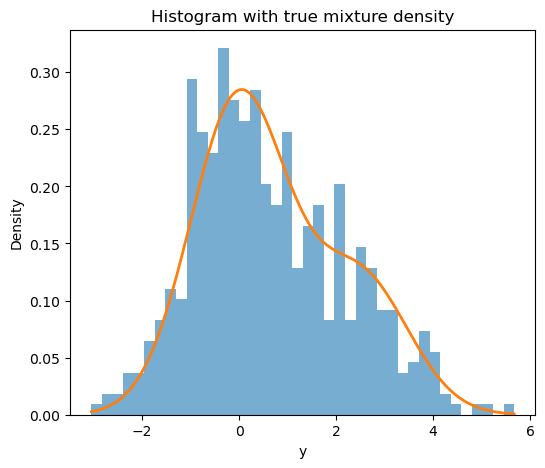

In [121]:
x = np.linspace(y.min(), y.max(), 500)

true_density = (1 - p) * norm.pdf(x, mu1_true, 1) + p * norm.pdf(x, mu2_true, 1)

plt.figure(figsize=(6,5))
plt.hist(y, bins=40, density=True, alpha=0.6)
plt.plot(x, true_density, linewidth=2)

plt.xlabel("y")
plt.ylabel("Density")
plt.title("Histogram with true mixture density")

plt.show()

Bayesian methods (and also non-Bayesian methods such as the EM algorithm for computing the MLE) crucially rely on the likelihood (as well as the log-likelihood). Below we plot the log-likelihood as a function of $\mu_1$ and $\mu_2$. 

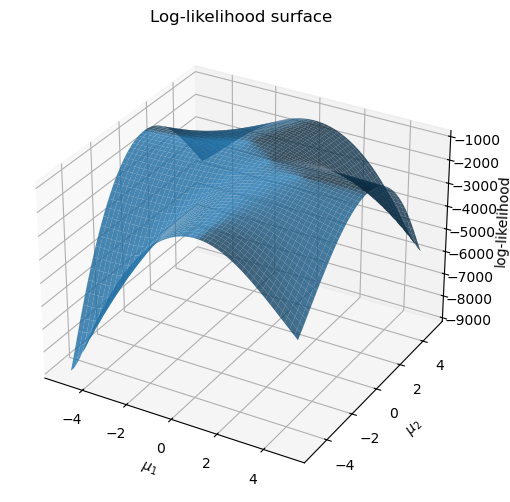

In [125]:
def loglik(mu1, mu2, y, p):
    comp1 = (1 - p) * norm.pdf(y[:, None, None] - mu1)
    comp2 = p * norm.pdf(y[:, None, None] - mu2)
    return np.sum(np.log(comp1 + comp2), axis=0)

mu1_grid = np.linspace(-5, 5, 200)
mu2_grid = np.linspace(-5, 5, 200)

M1, M2 = np.meshgrid(mu1_grid, mu2_grid, indexing="xy")
LL = loglik(M1, M2, y, p)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M1, M2, LL, alpha=0.8)

ax.set_xlabel(r'$\mu_1$')
ax.set_ylabel(r'$\mu_2$')
ax.set_zlabel('log-likelihood')

plt.title("Log-likelihood surface")
plt.show()

The log-likelihood does not seem like having a single mode; in fact, it has two modes as can be seen from the contour plot below. Notice however the scale of the z-axis in the log-likelihood plot. 

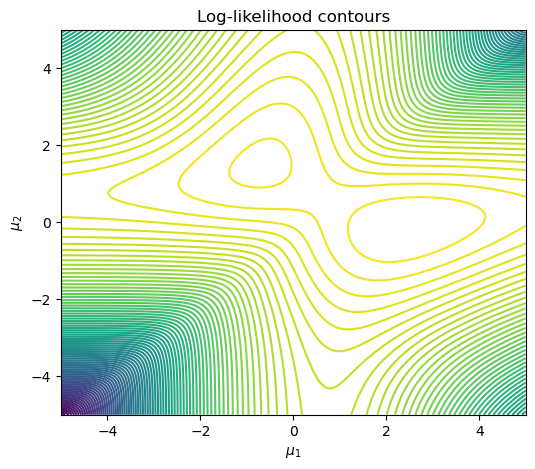

In [126]:
plt.figure(figsize=(6,5))
plt.contour(M1, M2, LL, levels=100)
plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours")
plt.show()

Of these two modes, one of them is quite close to the true values of $\mu_1$ and $\mu_2$ (which are $2.5$ and 0 respectively). The other one is a spurious mode. We should careful with any algorithm that tries to optimize (or sample from the posterior) based on the log-likelihood because it might be attracted by the spurious mode. 

If we look at the likelihood function (instead of the log-likelihood), it turns out it is extremely peaked with only one visible mode (which is close to the true values of $\mu_1$ and $\mu_2$). This is shown below. 

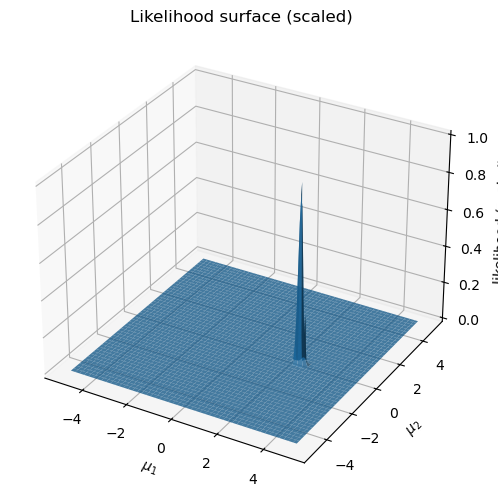

In [127]:
# stabilize before exponentiating
LL_shifted = LL - np.max(LL)
L = np.exp(LL_shifted)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(M1, M2, L, alpha=0.8)

ax.set_xlabel(r'$\mu_1$')
ax.set_ylabel(r'$\mu_2$')
ax.set_zlabel('likelihood (scaled)')

plt.title("Likelihood surface (scaled)")
plt.show()

It is remarkable that the bimodal structure in the log-likelihood seemingly disappears when we look at the likelihood which has a very clear and sharp peak. However, algorithms cannot directly run on the likelihood because it is mostly zero except for a very tiny region around the MLE. Note also that we have normalized the likelihood here so that the maximum is equal to 1. 

### The EM Algorithm

Before discussing the Gibbs sampler, let us first see how the EM algorithm works. The EM algorithm is an iterative algorithm applied to the log-likelihood for computing the MLE. It is very similar in spirit to the Gibbs sampler. The EM algorithm is coded below, we shall look at the algorithm in the next lecture. 

In [128]:
def em_gaussian_mixture(y, mu1_init, mu2_init, p=0.7,
                        max_iter=200, tol=1e-6):
    
    mu1 = mu1_init
    mu2 = mu2_init
    
    loglik_trace = []
    mu1_trace = [mu1]
    mu2_trace = [mu2]
    
    for t in range(max_iter):
        
        # ----- E-step -----
        f1 = (1 - p) * norm.pdf(y, loc=mu1, scale=1)
        f2 = p * norm.pdf(y, loc=mu2, scale=1)
        
        gamma = f2 / (f1 + f2)
        
        # ----- M-step -----
        mu1_new = np.sum((1 - gamma) * y) / np.sum(1 - gamma)
        mu2_new = np.sum(gamma * y) / np.sum(gamma)
        
        # ----- log-likelihood -----
        ll = np.sum(np.log(f1 + f2))
        loglik_trace.append(ll)
        
        mu1_trace.append(mu1_new)
        mu2_trace.append(mu2_new)
        
        # convergence
        if np.abs(mu1_new - mu1) < tol and np.abs(mu2_new - mu2) < tol:
            break
        
        mu1, mu2 = mu1_new, mu2_new
    
    return {
        "mu1": mu1,
        "mu2": mu2,
        "loglik": loglik_trace,
        "mu1_path": mu1_trace,
        "mu2_path": mu2_trace
    }

The EM algorithm needs an initial value for the parameters. Its behaviour could be different for different starting values as shown below. 

In [130]:
#consider the following initial values for the EM. 
#these values are chosen to be far from the true values (mu1_true = 2.5, mu2_true = 0.0)
mu1_init = 0.0
mu2_init = 3.0 
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)
print(res["mu1"], res["mu2"])

-0.6608832392943692 1.481701314811594


Here the EM algorithm converged to two values which are far from the true values. We can plot the EM iterates on the contour plot of the log-likelihood as shown below. 

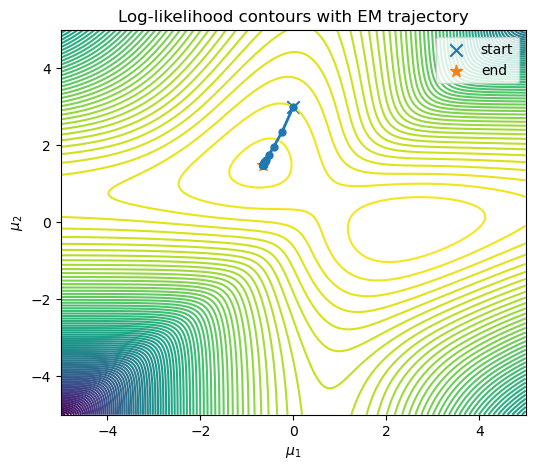

In [131]:
plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

It is clear from the above plot that the EM algorithm is converging to the spurious mode (as opposed to the correct mode). This solution does not explain the data well as is clear from the histogram of the data superimposed on the fitted density. 

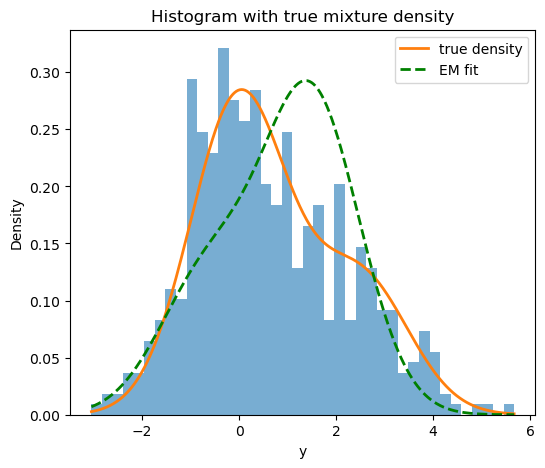

In [133]:
x = np.linspace(y.min(), y.max(), 500)
true_density = (1 - p) * norm.pdf(x, mu1_true, 1) + p * norm.pdf(x, mu2_true, 1)

mu1_alt = res["mu1"]
mu2_alt = res["mu2"]
alt_density = (1 - p) * norm.pdf(x, mu1_alt, 1) + p * norm.pdf(x, mu2_alt, 1)

plt.figure(figsize=(6,5))
plt.hist(y, bins=40, density=True, alpha=0.6)
plt.plot(x, true_density, linewidth=2, label = 'true density')
plt.plot(x, alt_density, linewidth=2, color='green', linestyle='--', label='EM fit')

plt.xlabel("y")
plt.ylabel("Density")
plt.title("Histogram with true mixture density")
plt.legend()

plt.show()

Below we take a different initialization for which the EM algorithm converges to the actual MLE. 

2.4614802836432386 -0.14232302968100252


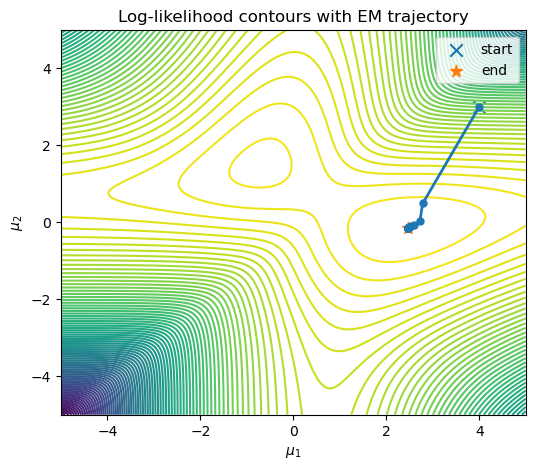

In [134]:
mu1_init = 4.0
mu2_init = 3.0 
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)
print(res["mu1"], res["mu2"])

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

If we initialize the EM algorithm randomly, one can still end up at the spurious mode. To see this, run the following a few times. 

-0.6608846315602165 1.4816987482385464


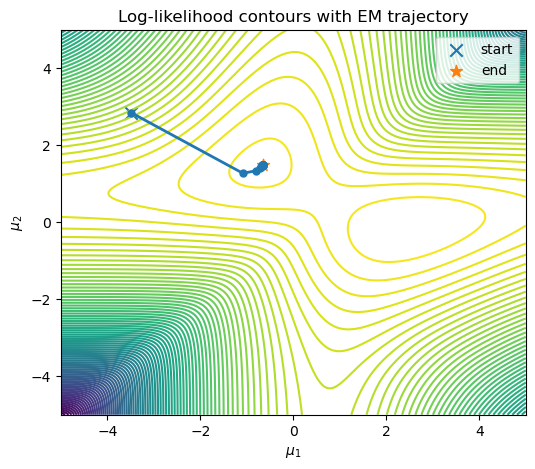

In [138]:
mu1_init = np.random.uniform(-5, 5)
mu2_init = np.random.uniform(-5, 5)
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)
print(res["mu1"], res["mu2"])

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

Another interesting initialization for the EM algorithm is when $\mu_1 = \mu_2$. In this case, it turns out that the EM algorithm converges (in one step!) to $(\bar{y}, \bar{y})$. So in this case, the algorithm does not even converge to one of the two modes. Instead it converges to the MLE in the single Gaussian model $N(\mu, 1)$. This can be verified below. 

0.6318113722352241 0.631811372235224


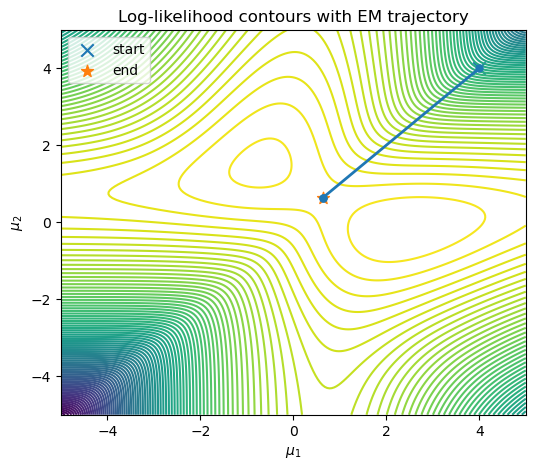

In [139]:
mu1_init = 4.0
mu2_init = 4.0
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)
print(res["mu1"], res["mu2"])

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

### The Gibbs Sampler

Next let us look at the Gibbs sampler. Gibbs sampler works by augmentation (similar to the probit regression example) and we shall look at the formulae in the next lecture. The code for the Gibbs sampler is given below. 

In [140]:
def gibbs_gaussian_mixture(y, mu1_init, mu2_init, p=0.7,
                          tau2=100, n_iter=5000):
    
    n = len(y)
    
    mu1 = mu1_init
    mu2 = mu2_init
    
    mu1_trace = []
    mu2_trace = []
    
    # initialize Z randomly
    z = np.random.rand(n) < p
    
    for t in range(n_iter):
        
        # ----- Sample Z -----
        f1 = (1 - p) * norm.pdf(y, loc=mu1)
        f2 = p * norm.pdf(y, loc=mu2)
        
        prob = f2 / (f1 + f2)
        z = np.random.rand(n) < prob
        
        # ----- Sample mu1 -----
        y1 = y[~z]
        n1 = len(y1)
        
        var1 = 1 / (n1 + 1/tau2)
        mean1 = var1 * np.sum(y1)
        
        mu1 = np.random.normal(mean1, np.sqrt(var1))
        
        # ----- Sample mu2 -----
        y2 = y[z]
        n2 = len(y2)
        
        var2 = 1 / (n2 + 1/tau2)
        mean2 = var2 * np.sum(y2)
        
        mu2 = np.random.normal(mean2, np.sqrt(var2))
        
        mu1_trace.append(mu1)
        mu2_trace.append(mu2)
    
    return {
        "mu1": np.array(mu1_trace),
        "mu2": np.array(mu2_trace)
    }

Similar to the EM algorithm, the Gibbs sampler also needs an initialization. We can run the Gibbs sampler with the same initial values that we used previously for the EM. Let us start with the first set of initial values. 

In [144]:
mu1_init = 0.0
mu2_init = 3.0 

res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)

mu1_samples = res_gibbs["mu1"]
mu2_samples = res_gibbs["mu2"]

Let us plot the Gibbs iterates below on contours. 

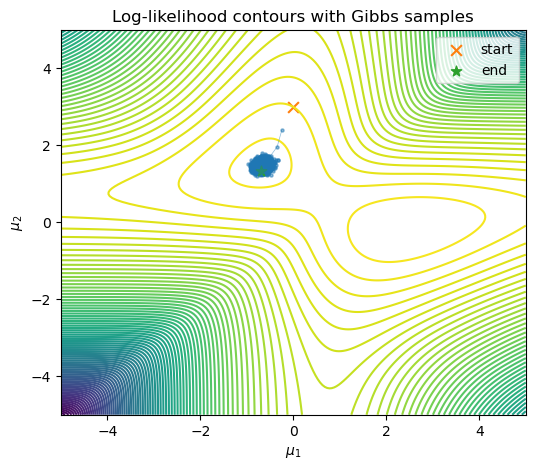

In [145]:
plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

Similar to the EM algorithm, the Gibbs sampler is only exploring the first peak of the posterior (note that this peak corresponds to the spurious mode). Let us now look at the second set of initial values. 

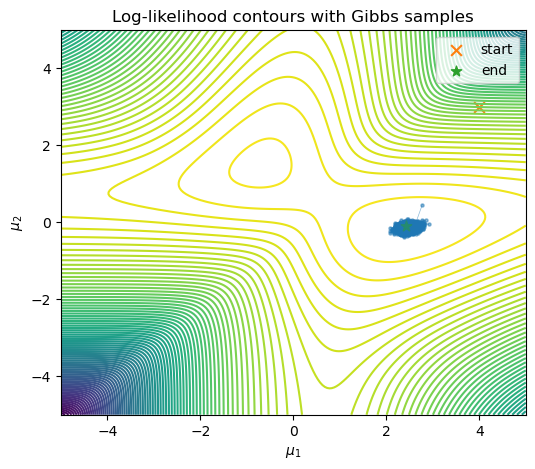

In [146]:
mu1_init = 4.0
mu2_init = 3.0 

res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)

mu1_samples = res_gibbs["mu1"]
mu2_samples = res_gibbs["mu2"]

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

In this case, the Gibbs samples are concentrated at the correct mode. Next let us look at random initializations. Repeat the following multiple times. There will be a few times the Gibbs samples focus on the spurious peak. 

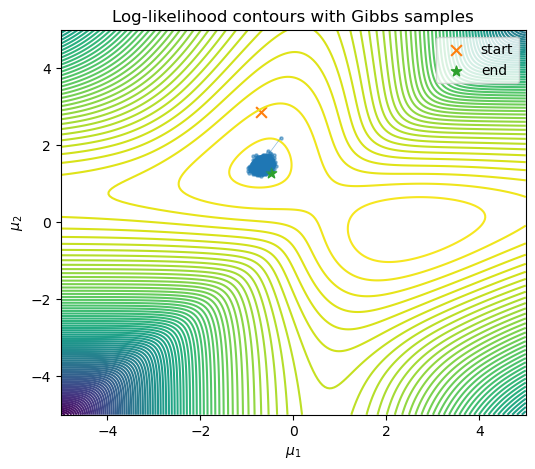

In [156]:
mu1_init = np.random.uniform(-5, 5)
mu2_init = np.random.uniform(-5, 5)
res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

Next look at the case of the initialization $\mu_1 = \mu_2$. In this case, the EM algorithm converges in one step to $(\bar{y}, \bar{y})$. Let us see how the Gibbs sampler performs. In this case (as can be seen from the code below), some times, the Gibbs sampler goes to the correct mode, but some other times, it will go to the spurious mode. This is an unstable initialization. 

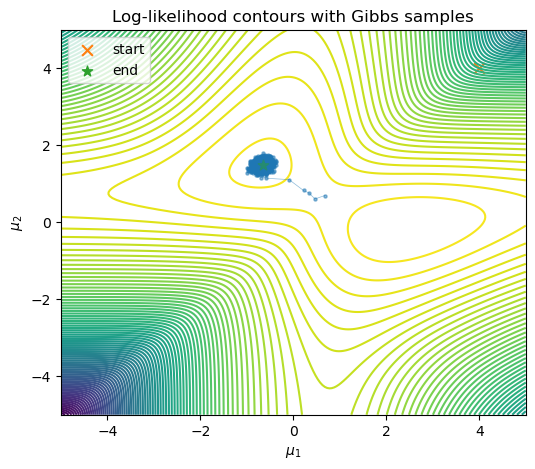

In [159]:
mu1_init = 4.0
mu2_init = 4.0
res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7)

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

Overall, the Gibbs sampler has very similar problems to the EM in this example.  Initialization is important and it is quite possible that the Gibbs samples are exploring the wrong peak of the log-posterior. 

### Metropolis Algorithm

Next let us look at the performance of the Random-Walk Metropolis Algorithm. The code is given below. We are generating proposals by $y = x + z$ where $z \sim N(0, s^2 I_2)$ for a step size $s$. 

In [160]:
def loglik(mu1, mu2, y, p):
    return np.sum(np.log((1 - p) * norm.pdf(y, mu1, 1) +
                         p * norm.pdf(y, mu2, 1)))

def rwm_mixture(y, mu1_init, mu2_init, p=0.7,
                n_iter=5000, step_size=1.0):
    
    mu1 = mu1_init
    mu2 = mu2_init
    
    mu1_trace = []
    mu2_trace = []
    
    accept = 0
    
    current_ll = loglik(mu1, mu2, y, p)
    
    for t in range(n_iter):
        
        # ----- proposal -----
        proposal = np.random.normal(0, step_size, size=2)
        mu1_prop = mu1 + proposal[0]
        mu2_prop = mu2 + proposal[1]
        
        # ----- compute log-likelihood -----
        prop_ll = loglik(mu1_prop, mu2_prop, y, p)
        
        # ----- accept/reject -----
        log_alpha = prop_ll - current_ll
        
        if np.log(np.random.rand()) < log_alpha:
            mu1, mu2 = mu1_prop, mu2_prop
            current_ll = prop_ll
            accept += 1
        
        mu1_trace.append(mu1)
        mu2_trace.append(mu2)
    
    return {
        "mu1": np.array(mu1_trace),
        "mu2": np.array(mu2_trace),
        "accept_rate": accept / n_iter
    }

The step size is crucial for the algorithm. When the step size equals 1, the Metropolis algorithm works correctly (i.e., has samples concentrated at the correct log-posterior mode) for all the initializations that we looked at previously. However the acceptance rate of the chain will be small. 

Acceptance rate: 0.01288


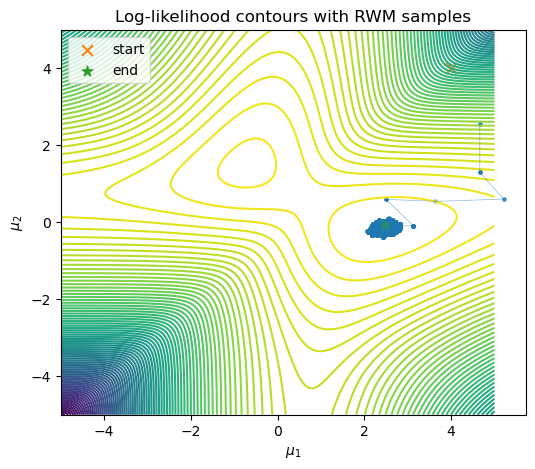

In [162]:
#First initialization
mu1_init = 0.0
mu2_init = 3.0

#Second initialization
mu1_init = 4.0
mu2_init = 3.0

#Random Initialization
mu1_init = np.random.uniform(-5, 5)
mu2_init = np.random.uniform(-5, 5)

#Fourth Initialization
mu1_init = 4.0
mu2_init = 4.0

res_rwm = rwm_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7, n_iter=100000, step_size = 1.0)

print("Acceptance rate:", res_rwm["accept_rate"])

plt.figure(figsize=(6,5))
plt.contour(M1, M2, LL, levels=100)

burn = 0
mu1_post = res_rwm["mu1"][burn:]
mu2_post = res_rwm["mu2"][burn:]

plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(res_rwm["mu1"][-1], res_rwm["mu2"][-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with RWM samples")

plt.legend()
plt.show()

On the other hand, when the step size is smaller (in this example, 0.5 or smaller), then the Metropolis algorithm behaves similarly to the Gibbs sampler case (with the possibility of exploring the spurious mode for certain initializations). 

Acceptance rate: 0.04871


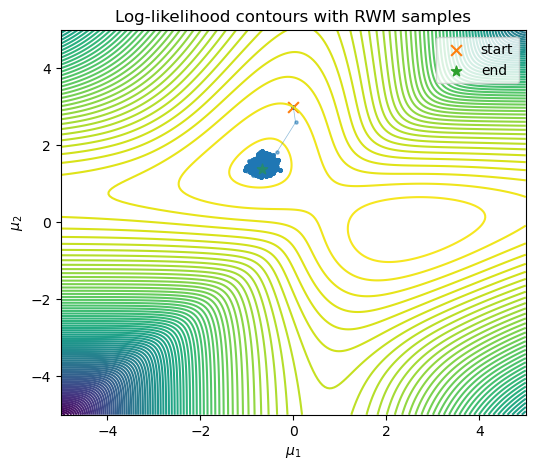

In [163]:
#First initialization
mu1_init = 0.0
mu2_init = 3.0

#Second initialization
#mu1_init = 4.0
#mu2_init = 3.0

#Random Initialization
#mu1_init = np.random.uniform(-5, 5)
#mu2_init = np.random.uniform(-5, 5)

#Fourth Initialization
#mu1_init = 4.0
#mu2_init = 4.0

res_rwm = rwm_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, p=0.7, n_iter=100000, step_size = 0.5)

print("Acceptance rate:", res_rwm["accept_rate"])

plt.figure(figsize=(6,5))
plt.contour(M1, M2, LL, levels=100)

burn = 0
mu1_post = res_rwm["mu1"][burn:]
mu2_post = res_rwm["mu2"][burn:]

plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(res_rwm["mu1"][-1], res_rwm["mu2"][-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with RWM samples")

plt.legend()
plt.show()

Overall, the summary from this simple simulation exercise is that the Gibbs sampler is sensitive to initialization in this simple mixture model. The Random-Walk Metropolis algorithm works with a large enough scale for the proposal chain. 